Step 1: Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

Step 2: Check GPU

In [2]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Step 3: Load MNIST Dataset

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(x_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


Step 4: Build CNN:Conv → ReLU → MaxPool

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(28,28,1), name='conv1'),

    layers.MaxPooling2D((2,2), name='pool1'),

    layers.Conv2D(64, (3,3), activation='relu',
                  name='conv2'),

    layers.MaxPooling2D((2,2), name='pool2'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Step 5: Compile Model

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Step 6: Train Model

In [6]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9359 - loss: 0.2215 - val_accuracy: 0.9828 - val_loss: 0.0589
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9818 - loss: 0.0590 - val_accuracy: 0.9862 - val_loss: 0.0474
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9881 - loss: 0.0390 - val_accuracy: 0.9865 - val_loss: 0.0468
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9906 - loss: 0.0303 - val_accuracy: 0.9885 - val_loss: 0.0344
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9926 - loss: 0.0237 - val_accuracy: 0.9870 - val_loss: 0.0456


Step 7: Evaluate Model

In [7]:
loss, accuracy = model.evaluate(x_test, y_test)

print(f"Test Accuracy: {accuracy*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9884 - loss: 0.0358
Test Accuracy: 98.84%


Step 8: Create Feature Extraction Model

In [8]:
feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer('conv1').output,
        model.get_layer('conv2').output
    ]
)

Step 9: Select Test Image

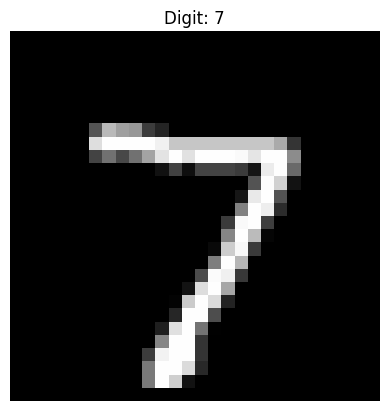

In [9]:
sample_image = x_test[0]

plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Digit: {y_test[0]}")
plt.axis('off')
plt.show()

Step 10: Extract Feature Maps

In [10]:
sample = np.expand_dims(sample_image, axis=0)

conv1_features, conv2_features = feature_model.predict(sample)

print("Conv1 Shape:", conv1_features.shape)
print("Conv2 Shape:", conv2_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
Conv1 Shape: (1, 26, 26, 32)
Conv2 Shape: (1, 11, 11, 64)


Step 11: Visualize Conv1 Feature Maps

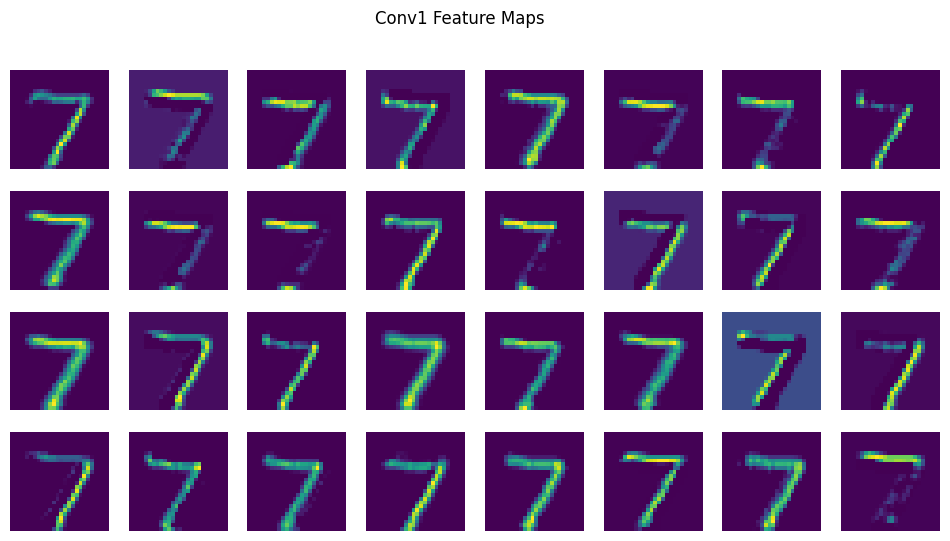

In [11]:
fig, axes = plt.subplots(4, 8, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(conv1_features[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.suptitle("Conv1 Feature Maps")
plt.show()

Step 12: Visualize Conv2 Feature Maps

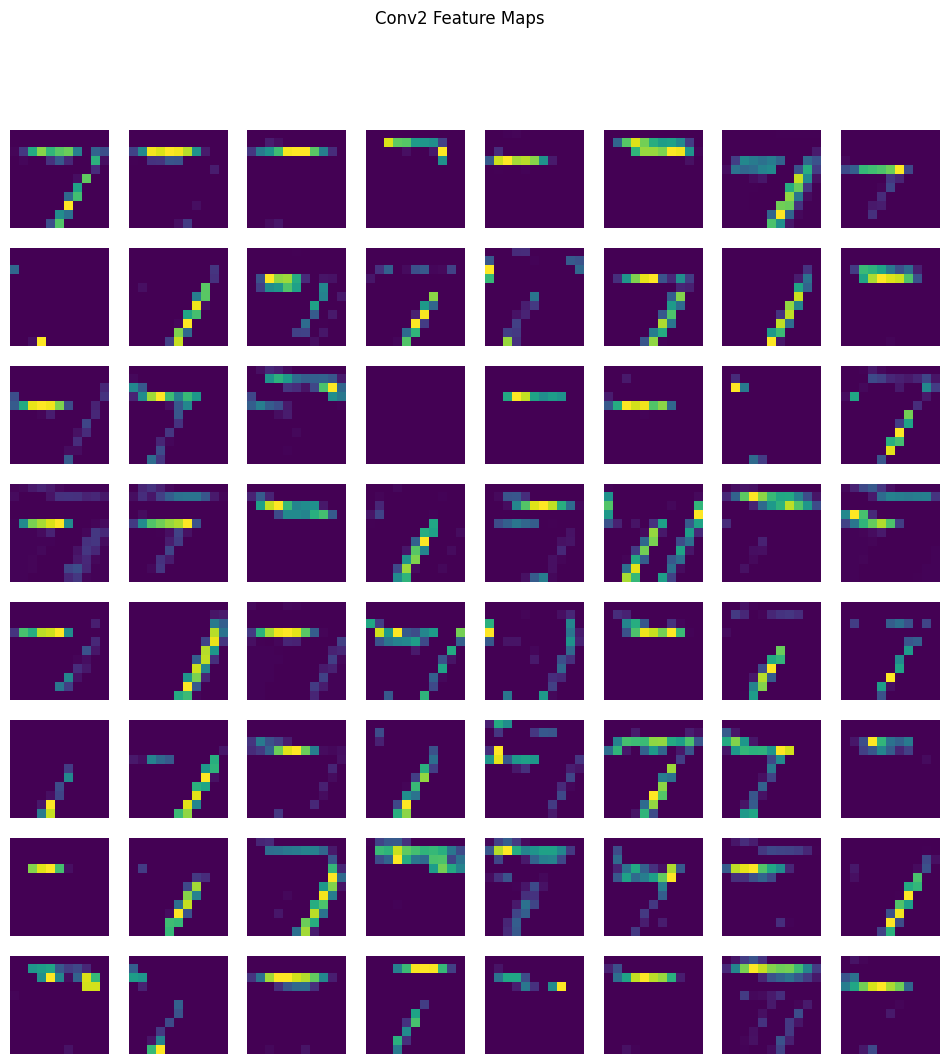

In [12]:
fig, axes = plt.subplots(8, 8, figsize=(12,12))

for i, ax in enumerate(axes.flat):
    ax.imshow(conv2_features[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.suptitle("Conv2 Feature Maps")
plt.show()

In [15]:
# Save images
plt.savefig("conv1_featuremaps.png", dpi=300)

# ... Conv2 code ...
plt.savefig("conv2_featuremaps.png", dpi=300)

# ... Output feature maps code ...
plt.savefig("output_featuremaps.png", dpi=300)

# =====================================
# Download Images
# =====================================

from google.colab import files

files.download("conv1_featuremaps.png")
files.download("conv2_featuremaps.png")
files.download("output_featuremaps.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>